<a href="https://colab.research.google.com/github/AnchalPandey29/Reinforcement-Learning-Agent/blob/main/RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random

In [ ]:
grid_size  = 5

start = (0,0)
goal = (4,4)

obstacles = [(0,3),(1,1),(2,3),(3,0)]

In [ ]:
#Action
#State
#QTable

In [ ]:
# Define Action

# 0 = up
# 1 = down
# 2 = left
# 3 = right

In [ ]:
actions = 4

In [ ]:
total_states = 25

In [ ]:
q_table = np.zeros((grid_size*grid_size,actions))

q_table

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
def get_state(pos):
  return pos[0]*grid_size+pos[1]

In [ ]:
def step(position,action):
  x,y = position

  if action == 0:
    x-=1
  elif action == 1:
    x+=1
  elif action ==2:
    y-=1
  elif action ==3:
    y+=1

  if x<0 or x>=grid_size or y<0 or y>=grid_size:
    return position, -5

  new_pos =(x,y)
  if new_pos in obstacles:
    return new_pos,-10
  if new_pos == goal:
    return new_pos, 10
  return new_pos, -1

In [ ]:
alpha = 0.1 #learning rate
gamma = 0.9 # discount factor - future reward importance
epsilon = 0.2 # exploration rate
episodes = 1000 # iterations

In [ ]:
for episode in range(episodes):
  position = start

  while position!=goal:
    state = get_state(position)
    #exploration
    if random.uniform(0,1)<epsilon:
      action = random.randint(0,3)
    #exploitation
    else:
      action = np.argmax(q_table[state])

    new_position, reward = step(position,action)

    new_state = get_state(new_position)

    old_value = q_table[state,action]
    next_max = np.max(q_table[new_state])

    new_value = old_value +alpha*(reward+gamma*next_max-old_value)

    q_table[state,action] =new_value
    position = new_position

print("Training completed")

Training completed


In [ ]:
position = start
path = [position]

while position != goal:
  state = get_state(position)
  action = np.argmax(q_table[state])
  position, reward = step(position,action)

  path.append(position)
print("Learned Path: ",path)

Learned Path:  [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]


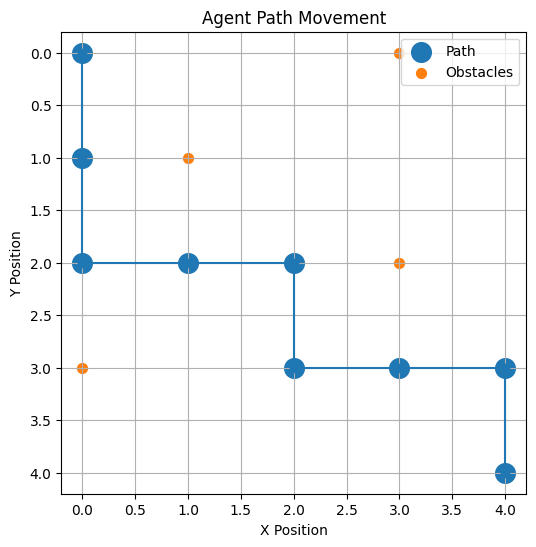

In [ ]:
import matplotlib.pyplot as plt

x = [p[1] for p in path]   # column
y = [p[0] for p in path]   # row
z1= [p[1] for p in obstacles]
z2 = [p[0] for p in obstacles]

plt.figure(figsize=(6,6))

plt.plot(x, y, marker='o', linestyle='-')

# plt.scatter(x[0], y[0], s=200, label="Start")
plt.scatter(x, y, s=200, label="Path")
plt.scatter(z1,z2, s=50, label="Obstacles")

plt.title("Agent Path Movement")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.grid(True)
plt.legend()
plt.gca().invert_yaxis()

plt.show()